# Stage 9 — Earth model validation and tuning

_Pipeline stage 9 of 14. This is the self-contained deep dive for the stage: narrative + analysis + interpretation, using the canonical `channel_heads` package and on-disk artifacts. Heavy rebuilds run via the `channel-heads` CLI (commands are given inline)._

## Honest validation + choosing an operating threshold

A single train/test split can be lucky. **Leave-one-basin-out (LOBO)** CV holds out
each basin in turn — the closest analogue to "apply to a brand-new landscape" — and is
our honest performance estimate. We then choose a **decision threshold**. The
F1-optimal point maximizes balanced accuracy on Earth; but Mars has *no labels*, so we
carry a **precision-oriented** operating point (max precision at recall ≥ 0.5) and study
the trade-off explicitly.

In [1]:
%matplotlib inline
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import channel_heads as ch
from channel_heads.io.paths import PROJECT_ROOT, RESULTS_DIR, EXAMPLE_DEMS
ROOT     = PROJECT_ROOT
MODELS   = ROOT / 'models'
MARS_OUT = ROOT / 'data/Mars/model_outputs'
MARS_IN  = ROOT / 'data/Mars/model_inputs'
MARS_DIR = ROOT / 'data/Mars'
REGIMES_ = ['regA', 'regB', 'regC']
RC = {'regA': '#e41a1c', 'regB': '#377eb8', 'regC': '#4daf4a'}
MODEL_FEATURES = ['orientation_diff_deg','headhead_dist_norm','apex_angle_deg',
                  'strahler_order_diff','proximity_profile_norm']
def _load_op_thr(r):  # per-regime operating threshold, read from disk (auto-tracks retrains)
    p = MODELS / f'optimal_threshold_geom_plus_cnn_emb_{r}.txt'
    return float(p.read_text().strip()) if p.exists() else float('nan')
OP_THR = {r: _load_op_thr(r) for r in REGIMES_}
def _abs(p):
    p = Path(p); return p if p.is_absolute() else ROOT / p
print('channel_heads', ch.__version__, '| root', ROOT)


channel_heads 0.1.0 | root /Users/guypi/Projects/channel-heads


### 1 · LOBO cross-validation (pooled + per-fold)

,config,n,n_basins,pooled_auc,fold_auc_mean,fold_auc_std,threshold,precision,recall,f1,accuracy
0,baseline,5413,17,0.915659,0.887589,0.091805,0.868746,0.894996,0.500918,0.642331,0.775540
1,regA,23742,17,0.881405,0.840010,0.094690,0.768710,0.766349,0.500353,0.605423,0.805703
2,regB,10612,17,0.894679,0.851604,0.141186,0.805332,0.814761,0.500000,0.619703,0.807199
3,regC,28954,17,0.702216,0.917383,0.044368,0.441177,0.413317,0.500000,0.452545,0.692409


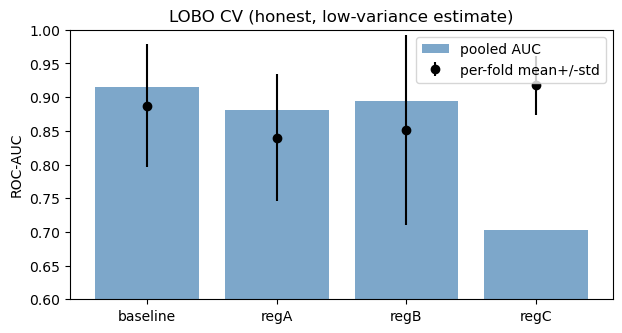

In [2]:
p = MODELS / 'lobo_cv_metrics.csv'
lobo = pd.read_csv(p) if p.exists() else pd.DataFrame()
display(lobo)
if not lobo.empty:
    fig, ax = plt.subplots(figsize=(7, 3.5))
    ax.bar(lobo.config, lobo.pooled_auc, color='steelblue', alpha=0.7, label='pooled AUC')
    ax.errorbar(lobo.config, lobo.fold_auc_mean, yerr=lobo.fold_auc_std, fmt='o', color='k', label='per-fold mean+/-std')
    ax.set_ylabel('ROC-AUC'); ax.set_ylim(0.6, 1.0); ax.set_title('LOBO CV (honest, low-variance estimate)'); ax.legend(); plt.show()

### 2 · ROC / PR on held-out outlets (regA combined)

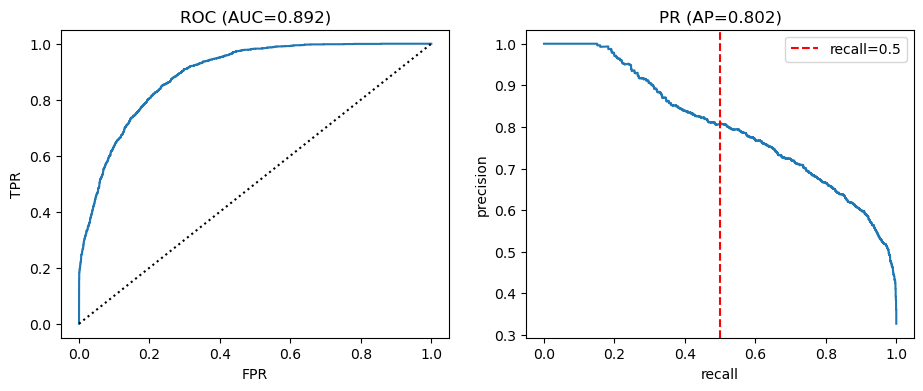

In [3]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import roc_curve, precision_recall_curve, roc_auc_score, average_precision_score, f1_score
from xgboost import XGBClassifier
d = pd.read_csv(RESULTS_DIR / 'master_dataset_regA_with_emb.csv')
feats = MODEL_FEATURES + [f'emb_{i}' for i in range(4)]
d['grp'] = d.basin.astype(str) + '__' + d.outlet.astype(str)
tr, te = next(GroupShuffleSplit(1, test_size=0.2, random_state=42).split(d, d.y, d.grp))
mdl = XGBClassifier(); mdl.load_model(str(MODELS / 'xgb_geom_plus_cnn_emb_regA.json'))
proba = mdl.predict_proba(d.iloc[te][feats].to_numpy())[:, 1]; y = d.iloc[te].y.to_numpy()
fig, axs = plt.subplots(1, 2, figsize=(11, 4))
fpr, tpr, _ = roc_curve(y, proba); axs[0].plot(fpr, tpr); axs[0].plot([0,1],[0,1],'k:')
axs[0].set_title(f'ROC (AUC={roc_auc_score(y,proba):.3f})'); axs[0].set_xlabel('FPR'); axs[0].set_ylabel('TPR')
pr, rc, _ = precision_recall_curve(y, proba); axs[1].plot(rc, pr)
axs[1].axvline(0.5, color='r', ls='--', label='recall=0.5'); axs[1].legend()
axs[1].set_title(f'PR (AP={average_precision_score(y,proba):.3f})'); axs[1].set_xlabel('recall'); axs[1].set_ylabel('precision'); plt.show()

### 3 · Threshold trade-off: precision / recall / F1

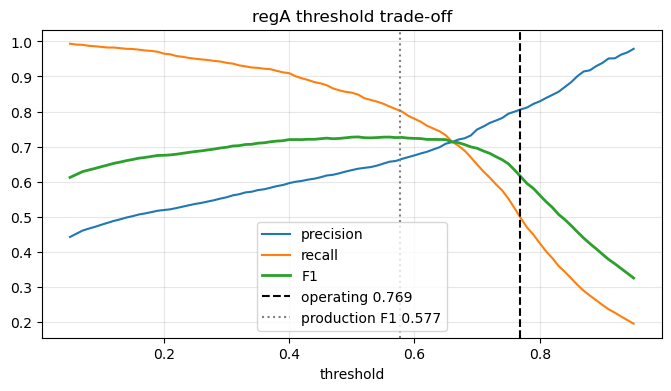

operating thresholds (max-precision @ recall>=0.5), used for Mars:
  regA: 0.769133
  regB: 0.773238
  regC: 0.810635


In [4]:
ts = np.linspace(0.05, 0.95, 91)
P = [(((proba>=t)&(y==1)).sum()/max((proba>=t).sum(),1)) for t in ts]
R = [(((proba>=t)&(y==1)).sum()/max((y==1).sum(),1)) for t in ts]
F = [f1_score(y, (proba>=t).astype(int)) for t in ts]
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ts, P, label='precision'); ax.plot(ts, R, label='recall'); ax.plot(ts, F, label='F1', lw=2)
ax.axvline(OP_THR['regA'], color='k', ls='--', label=f"operating {OP_THR['regA']:.3f}")
ax.axvline(0.577406, color='gray', ls=':', label='production F1 0.577')
ax.set_xlabel('threshold'); ax.set_title('regA threshold trade-off'); ax.legend(); ax.grid(alpha=0.3); plt.show()
print('operating thresholds (max-precision @ recall>=0.5), used for Mars:')
for r in REGIMES_:
    tt = MODELS / f'optimal_threshold_geom_plus_cnn_emb_{r}.txt'
    if tt.exists(): print(f'  {r}: {tt.read_text().split()[0]}')

**Takeaway.** LOBO ROC-AUC ~0.88 (regA/regB) confirms the model generalizes to
unseen basins, not just unseen outlets. The threshold curves show why the choice
matters: the precision-oriented operating point (~0.76) buys high precision at the
cost of recall — appropriate for label-free Mars, where false couplings would
contaminate the rate. The Earth F1 point (0.577) is **not** copied to Mars; Stage 12
studies that sensitivity directly.